# VLM Visual Skills Data Analysis Pipeline
This notebook contains the evaluation, error analysis, and visualization pipeline for video highlight detection and calibration.

In [1]:
import sys
import io
import os
import json
import time
import warnings
import h5py
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Using notebook-friendly tqdm
from scipy.interpolate import interp1d
from scipy.stats import spearmanr, kendalltau
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter1d
from decord import VideoReader, cpu
from collections import Counter
from scipy.spatial import ConvexHull

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from vslice_utils.models import load_vlm, minicpm_extract_title_and_keywords, qwen_extract_title_and_keywords, minicpm_inference, qwen_inference
from vslice_utils.dataloader import build_summe_manifest, build_tvsum_manifest, VideoSegmentDataset
from vslice_utils.measure_calibration import soft_expected_calibration_error
from vslice_utils.helpers import set_seed, temporal_process_features

# Evaluation dependencies
# Jupyter doesn't support __file__, so we use os.path.abspath('')
sys.path.insert(0, os.path.join(os.path.abspath(''), '..', 'csta'))
try:
    from generate_summary import generate_summary
    from evaluation_metrics import get_corr_coeff
    from utils import get_gt
except ImportError:
    generate_summary = get_corr_coeff = get_gt = None

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*not a valid Python identifier.*")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

# Fix Windows console encoding for non-ASCII characters
if sys.platform == "win32":
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding="utf-8", errors="replace")

## 1. Evaluation & Metrics
Functions to compute F-score, ECE, correlations, and extract skills.

In [36]:
def compute_video_metrics(yes_scores, no_scores, h5_path, h5_key, video_name, dataset_name, user_scores=None, use_advanced_scoring=False, epsilon=1e-8):
    """
    Calculates F-score, correlations, and ECE using VLM probabilities.
    """
    with h5py.File(h5_path, 'r') as f:
        grp = f[h5_key]
        features = grp['features'][()]
        cps = grp['change_points'][...]
        n_frames = int(grp['n_frames'][...])
        picks = grp['picks'][...]
        gt_scores = grp['gtscore'][...]
        user_summaries = grp['user_summary'][...] if 'user_summary' in grp else [grp['gtsummary'][...]]

    if use_advanced_scoring:
        motion_features = temporal_process_features(features)
        smoothed_motion = gaussian_filter1d(motion_features, sigma=2.0)
        motion_weight = smoothed_motion / (np.mean(smoothed_motion) + epsilon)

        threshold = np.percentile(yes_scores, 95)
        boring_mask = yes_scores < threshold
        
        if not np.any(boring_mask):
            global_feat = np.mean(features, axis=0, keepdims=True)
        else:
            global_feat = np.mean(features[boring_mask], axis=0, keepdims=True)

        features_tensor = torch.tensor(features, dtype=torch.float32)
        global_feat_tensor = torch.tensor(global_feat, dtype=torch.float32)

        relevance_weight = 1.0 - F.cosine_similarity(features_tensor, global_feat_tensor)
        relevance_weight = relevance_weight / (torch.mean(relevance_weight) + epsilon)

        final_scores = yes_scores * motion_weight
        scores = (final_scores - np.min(final_scores)) /(np.max(final_scores) - np.min(final_scores))
    else:
        scores = yes_scores
        
    scores_list = np.squeeze(scores).tolist()
    summary = generate_summary([cps], [scores_list], [n_frames], [picks])[0]
        
    f_scores = []
    for user_summary in user_summaries:
        min_len = min(len(summary), len(user_summary))
        s = summary[:min_len]
        u = user_summary[:min_len]
        
        intersection = np.sum(s * u)
        sum_s = np.sum(s)
        sum_u = np.sum(u)
        
        precision = intersection / sum_s if sum_s > 0 else 0
        recall = intersection / sum_u if sum_u > 0 else 0
        
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
        f_scores.append(f1)
    
    if dataset_name == 'summe':
        rho, tau = get_corr_coeff([summary], [h5_key], 'SumMe', user_summaries)
    else:
        rho, tau = get_corr_coeff([scores_list], [h5_key], 'TVSum', user_scores)

    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    gt_scores_tensor = torch.tensor(gt_scores, dtype=torch.float32)
    global_gt_2d = torch.stack([1.0 - gt_scores_tensor, gt_scores_tensor], dim=1)
    
    p_yes_preds = torch.ones_like(scores_tensor)
    ece = soft_expected_calibration_error(scores_tensor, p_yes_preds, global_gt_2d, num_bins=15)
    
    return {
        "video": video_name,
        "dataset": dataset_name,
        "f_score": np.max(f_scores) if dataset_name == 'summe' else np.mean(f_scores),
        "spearman": rho,
        "kendall": tau,
        "n_frames": n_frames,
        "n_segments": len(cps),
        "ECE": ece
    }

def save_skill(idx, pool, skill_type, error_val, picks, fps, video_id, safe_title, 
               img_dir, all_frames_for_video, cleaned_title, keywords,
               temporal_diff, embedding, logit_yes, logit_no):
    
    sec = picks[idx] / fps
    time_str = f"{int(sec // 60):02d}:{int(sec % 60):02d}"
    img_name = f"{skill_type}_{video_id}_{safe_title}.jpg"
    img_path = os.path.join(img_dir, img_name)
    all_frames_for_video[idx].save(img_path)
    
    pool.append({
            "video_id": video_id,
            "image_path": img_path,
            "title": cleaned_title,
            "keywords": keywords,
            "time": time_str,
            "time_sec": float(sec),
            "frame_idx": int(idx),
            "type": skill_type,
            "error": float(error_val),
            "temporal_diff": float(temporal_diff),
            "embedding": embedding,
            "logit_yes": float(logit_yes),
            "logit_no": float(logit_no)
        })
    return time_str, img_name

def apply_motion_weighting(features, yes_scores, sigma=2.0, epsilon=1e-8):
    motion_features = temporal_process_features(features)
    smoothed_motion = gaussian_filter1d(motion_features, sigma=sigma)
    
    # 2. Mean-normalized motion weight
    motion_weight = smoothed_motion / (np.mean(smoothed_motion) + epsilon)

    # 3. Multiplicative fusion (Logical AND)
    final_scores = yes_scores * motion_weight
    
    # 4. Min-max normalization safely
    score_range = np.max(final_scores) - np.min(final_scores)
    scores = (final_scores - np.min(final_scores)) / (score_range + epsilon)
    
    return scores

## 3. Run Configuration & Main Extraction Pipeline
Iterates over dataset splits, infers highlight scores, computes errors, and stores skill embeddings.

In [3]:
class Args:
    model_type = "minicpm"
    dataset = "summe"
    root_dir = "/home/dexter/LLaVA-VLS"
    output_dir = "/home/dexter/VideoRAG/vslice_features/"
    model_path = None
    split_file = "/home/dexter/VideoRAG/dataset/summe_splits.json"

def resolve_model_path(mtype):
    if mtype == "qwen": return "Qwen/Qwen3.5-9B"
    candidates = ["./MiniCPM-V-2_6-int4", "/home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4"]
    for p in candidates:
        if os.path.exists(p): return p
    return "openbmb/MiniCPM-V-2_6"

# Initialize and Run
args = Args()

if args.model_path is None:
    args.model_path = resolve_model_path(args.model_type)

In [56]:
manifest = []
if args.dataset in ("summe", "both"):
    manifest.extend(build_summe_manifest(args.root_dir))
    dataset_name = "summe"

if args.dataset in ("tvsum", "both"):
    manifest.extend(build_tvsum_manifest(args.root_dir))
    dataset_name = "tvsum"

summe_h5 = os.path.join(args.root_dir, "SumMe", "eccv16_dataset_summe_google_pool5.h5")
tvsum_h5 = os.path.join(args.root_dir, "TVSum", "eccv16_dataset_tvsum_google_pool5.h5")

# Load VLM
print(f"Loading {args.model_type.upper()} model...")
vlm_vars = load_vlm(args.model_path, args.model_type, device)
model, processor, yes_id, no_id = vlm_vars[0], vlm_vars[2], vlm_vars[3], vlm_vars[4]

splits = []
if args.split_file and os.path.exists(args.split_file):
    with open(args.split_file, 'r') as f:
        splits = json.load(f)
    print(f"Loaded {len(splits)} splits from {args.split_file}")

# --- 1. INITIALIZE GLOBAL STORAGE ---
dataset_hiddens = []
dataset_gts = []
dataset_tps = []
dataset_fps = []

tp_memory_bank, fp_memory_bank, tn_memory_bank, fn_memory_bank = [], [], [], []
tp_temp_bank, fp_temp_bank, tn_temp_bank, fn_temp_bank = [], [], [], []

# --- 2. START EXTRACTION LOOP ---
for split_idx, split in enumerate(splits[:1]):
    print(f"\n==================== SPLIT {split_idx+1}/{len(splits)} ====================")
    
    train_set = split.get('train_keys', [])
    print(f"Acquiring visual skills from {len(train_set)} training videos...")

    for video_id in tqdm(train_set, desc="Training"):
        item = next((m for m in manifest if m['h5_key'] == video_id), None)
        if not item: continue

        video_path, title, dataset_name_item = item["video_path"], item["title"], item["dataset"]
        picks, gtscore = item["picks"], item["gtscore"]

        # Loader for raw frames
        dataset = VideoSegmentDataset(video_path, segment_length=64, width=896, height=672, picks=picks)
        loader = DataLoader(dataset, batch_size=None, shuffle=False, num_workers=4)

        # Meta-data extraction
        if args.model_type == "minicpm":
            cleaned_title, keywords = minicpm_extract_title_and_keywords(title, model, processor)
        else:
            cleaned_title, keywords = qwen_extract_title_and_keywords(title, model)

        # Load motion/temporal features from H5
        h5_path = summe_h5 if dataset_name_item == "summe" else tvsum_h5
        with h5py.File(h5_path, 'r') as f:
            grp = f[video_id]
            video_features = grp['features'][()]

        all_p_yes, all_hidden_states = [], []

        # --- VLM INFERENCE ---
        pbar = tqdm(loader, desc=f"VLM: {cleaned_title}", leave=False)
        for frames, start, end in pbar:
            if args.model_type == "minicpm":
                p_yes, _, _, _, hidden_states = minicpm_inference(frames, cleaned_title, keywords, model, processor, yes_id, no_id)
            else:
                p_yes, _, _, _, hidden_states = qwen_inference(frames, cleaned_title, keywords, model, yes_id, no_id)

            all_p_yes.append(p_yes.detach())
            all_hidden_states.append(hidden_states.detach().float())

        # Concatenate full video results
        raw_p_yes = torch.cat(all_p_yes, dim=0).flatten()
        raw_hidden_states = torch.cat(all_hidden_states, dim=0)
        gt_tensor = torch.from_numpy(gtscore).to(device).float().flatten()

        # Temporal Diff Extraction
        temp_diffs = temporal_process_features(video_features)
        temp_diffs_tensor = torch.tensor(temp_diffs, dtype=torch.float, device=device).flatten()

        # Video-level Normalization for Hidden States
        v_mean = raw_hidden_states.mean(dim=0, keepdim=True)
        v_std = raw_hidden_states.std(dim=0, keepdim=True) + 1e-8
        raw_hidden_states = (raw_hidden_states - v_mean) / v_std

        # --- MINE ANCHORS FROM ERROR ---
        pos_thresh = torch.quantile(gt_tensor, 0.75) 
        neg_thresh = torch.quantile(gt_tensor, 0.25)
        abs_error = torch.abs(raw_p_yes - gt_tensor)
        
        tp_mask = (abs_error <= 0.2) & (gt_tensor >= pos_thresh)
        tn_mask = (abs_error <= 0.2) & (gt_tensor <= neg_thresh)
        fp_mask = (abs_error >= 0.3) & (gt_tensor <= neg_thresh)
        fn_mask = (abs_error >= 0.3) & (gt_tensor >= pos_thresh)

        # --- STORE FOR GRU (Full Sequences) ---
        dataset_hiddens.append(raw_hidden_states.detach().cpu())
        dataset_gts.append(gt_tensor.detach().cpu())
        dataset_tps.append(tp_mask.detach().cpu())
        dataset_fps.append(fp_mask.detach().cpu())

        # --- STORE FOR BANKS (Fragments) ---
        if tp_mask.any():
            tp_memory_bank.append(raw_hidden_states[tp_mask].detach())
            tp_temp_bank.append(temp_diffs_tensor[tp_mask].detach())
        if fp_mask.any():
            fp_memory_bank.append(raw_hidden_states[fp_mask].detach())
            fp_temp_bank.append(temp_diffs_tensor[fp_mask].detach())
        if tn_mask.any():
            tn_memory_bank.append(raw_hidden_states[tn_mask].detach())
            tn_temp_bank.append(temp_diffs_tensor[tn_mask].detach())
        if fn_mask.any():
            fn_memory_bank.append(raw_hidden_states[fn_mask].detach())
            fn_temp_bank.append(temp_diffs_tensor[fn_mask].detach())
            
    tp_anchors = F.normalize(torch.cat(tp_memory_bank, dim=0), p=2, dim=1)
    fp_anchors = F.normalize(torch.cat(fp_memory_bank, dim=0), p=2, dim=1)
    tn_anchors = F.normalize(torch.cat(tn_memory_bank, dim=0), p=2, dim=1)
    fn_anchors = F.normalize(torch.cat(fn_memory_bank, dim=0), p=2, dim=1)

    tp_temps = F.normalize(torch.cat(tp_temp_bank, dim=0), p=2, dim=0)
    fp_temps = F.normalize(torch.cat(fp_temp_bank, dim=0), p=2, dim=0)
    tn_temps = F.normalize(torch.cat(tn_temp_bank, dim=0), p=2, dim=0)
    fn_temps = F.normalize(torch.cat(fn_temp_bank, dim=0), p=2, dim=0)
    print(f"Memory Bank Sizes | TP: {tp_anchors.size(0)}, FP: {fp_anchors.size(0)}, TN: {tn_anchors.size(0)}, FN: {fn_anchors.size(0)}")

[DATA] SumMe: 25 videos discovered
Loading MINICPM model...
[cuda] Loading minicpm from /home/dexter/VideoRAG/.checkpoints/MiniCPM-V-2_6-int4...


Loading weights:   0%|          | 0/789 [00:00<?, ?it/s]

[cuda] [OK] MiniCPM Loaded (Yes=9454, No=2753)
Loaded 5 splits from /home/dexter/VideoRAG/dataset/summe_splits.json

==================== SPLIT 1/5 ====================
Acquiring visual skills from 20 training videos...


Training:   0%|          | 0/20 [00:00<?, ?it/s]

VLM: Air Force One:   0%|          | 0/5 [00:00<?, ?it/s]

...

VLM: Bus in Rock Tunnel:   0%|          | 0/6 [00:00<?, ?it/s]

VLM: Car railcross:   0%|          | 0/6 [00:00<?, ?it/s]

VLM: Cockpit Landing:   0%|          | 0/10 [00:00<?, ?it/s]

VLM: Cooking:   0%|          | 0/2 [00:00<?, ?it/s]

Memory Bank Sizes | TP: 567, FP: 1274, TN: 717, FN: 893



📊 4-QUADRANT LATENT MEMORY BANK STATISTICAL REPORT
Total TP Anchors (Correct Peaks):   567
Total FP Anchors (Hallucinations):  1274
Total TN Anchors (Correct Valleys): 717
Total FN Anchors (Missed Peaks):    893
----------------------------------------------------------------------
1. PCA PROJECTION STATS
   - PC1 Explained Variance:     26.47%
   - PC2 Explained Variance:     19.59%
   - Total 2D Explained Var:     46.06%
----------------------------------------------------------------------
2. COSINE SIMILARITY DISTRIBUTIONS
   - TP-TP (Peak Cohesion)     | Mean: 0.0483 | Std: 0.3570
   - FP-FP (False Cohesion)    | Mean: 0.0910 | Std: 0.3354
   - TN-TN (Valley Cohesion)   | Mean: 0.2789 | Std: 0.3289
   - FN-FN (Miss Cohesion)     | Mean: 0.1258 | Std: 0.3650
   - TP-FP (Peak Separation)   | Mean: -0.0069 | Std: 0.3289
   - TN-FN (Valley Separation) | Mean: -0.1119 | Std: 0.2599
   - TP-TN (Global Separation) | Mean: -0.0033 | Std: 0.3610
-------------------------------------------

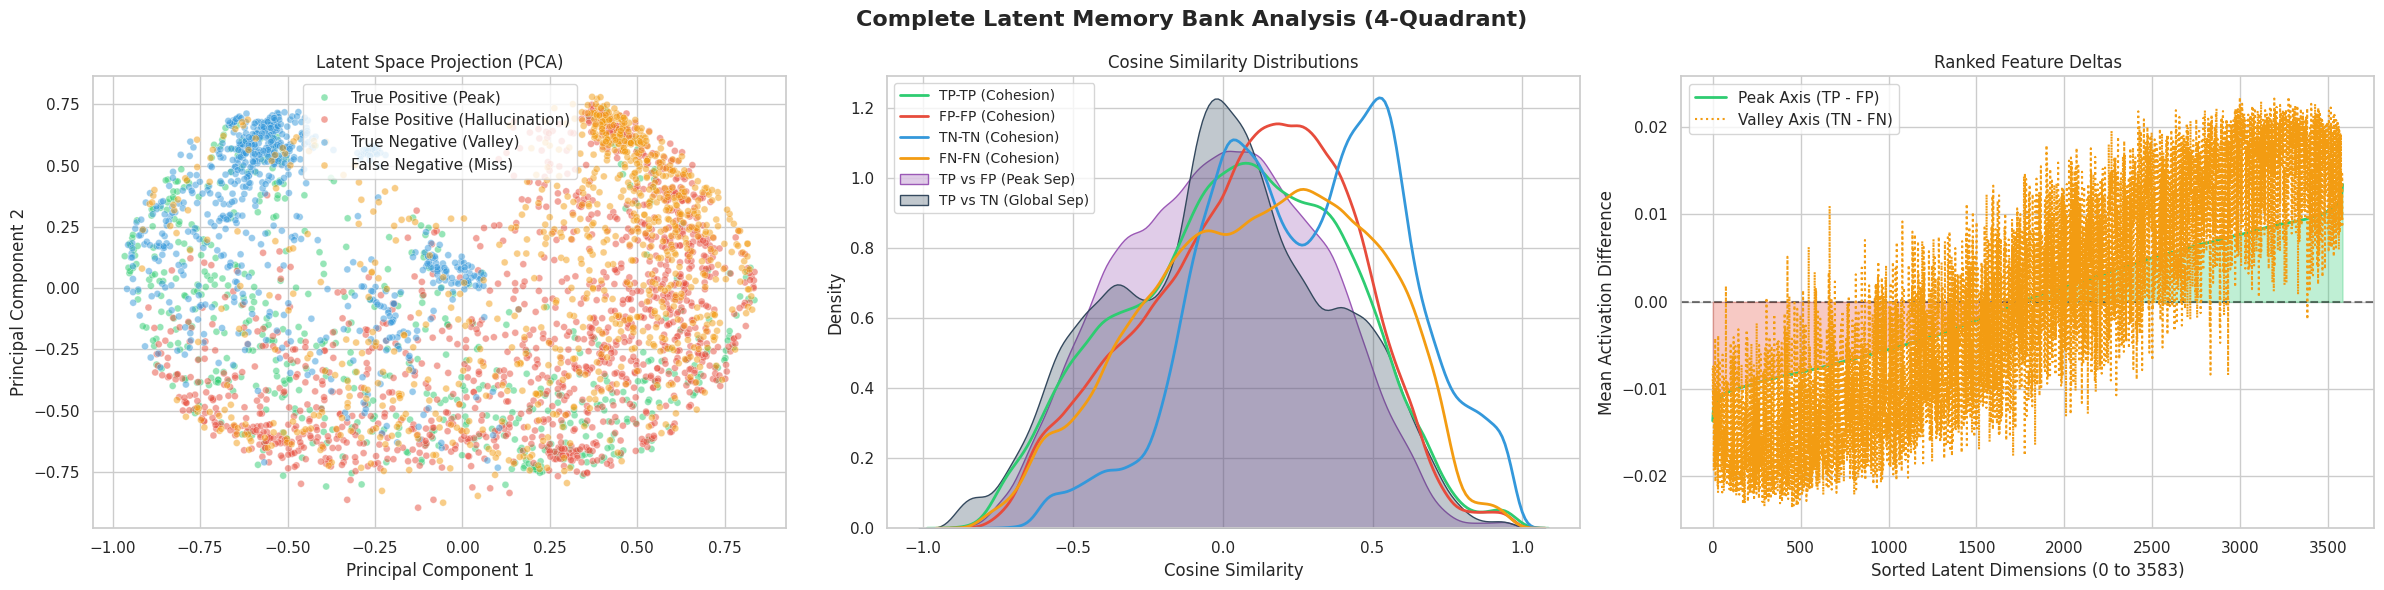

In [57]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Prepare Data for Plotting (Move to CPU & Numpy)
# ---------------------------------------------------------
tp_np = tp_anchors.cpu().numpy()
fp_np = fp_anchors.cpu().numpy()
tn_np = tn_anchors.cpu().numpy()
fn_np = fn_anchors.cpu().numpy()

# Create labels mapping
labels_list = (
    ["True Positive (Peak)"] * tp_np.shape[0] + 
    ["False Positive (Hallucination)"] * fp_np.shape[0] +
    ["True Negative (Valley)"] * tn_np.shape[0] +
    ["False Negative (Miss)"] * fn_np.shape[0]
)
labels = np.array(labels_list)
all_anchors = np.vstack([tp_np, fp_np, tn_np, fn_np])

# ---------------------------------------------------------
# 2. Setup Figure & Run PCA
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Complete Latent Memory Bank Analysis (4-Quadrant)", fontsize=16, weight='bold')

pca = PCA(n_components=2)
projected = pca.fit_transform(all_anchors)

# ---------------------------------------------------------
# 3. Calculate Stats for Reporting
# ---------------------------------------------------------
# Helper function to safely subsample without crashing on empty banks
def get_subsample(arr, size=2000):
    if arr.shape[0] == 0: return arr
    n = min(size, arr.shape[0])
    idx = np.random.choice(arr.shape[0], n, replace=False)
    return arr[idx]

tp_sub = get_subsample(tp_np)
fp_sub = get_subsample(fp_np)
tn_sub = get_subsample(tn_np)
fn_sub = get_subsample(fn_np)

# Intra-class (Cohesion) similarities
def calc_sim_intra(arr):
    if arr.shape[0] < 2: return np.array([0.0])
    return np.dot(arr, arr.T)[np.triu_indices(arr.shape[0], k=1)]

sim_tp_tp = calc_sim_intra(tp_sub)
sim_fp_fp = calc_sim_intra(fp_sub)
sim_tn_tn = calc_sim_intra(tn_sub)
sim_fn_fn = calc_sim_intra(fn_sub)

# Inter-class (Separation) similarities
sim_tp_fp = np.dot(tp_sub, fp_sub.T).flatten() if tp_sub.shape[0] > 0 and fp_sub.shape[0] > 0 else np.array([0.0])
sim_tn_fn = np.dot(tn_sub, fn_sub.T).flatten() if tn_sub.shape[0] > 0 and fn_sub.shape[0] > 0 else np.array([0.0])
sim_tp_tn = np.dot(tp_sub, tn_sub.T).flatten() if tp_sub.shape[0] > 0 and tn_sub.shape[0] > 0 else np.array([0.0])

# Feature Deltas
tp_mean = tp_np.mean(axis=0) if tp_np.shape[0] > 0 else np.zeros(3584)
fp_mean = fp_np.mean(axis=0) if fp_np.shape[0] > 0 else np.zeros(3584)
tn_mean = tn_np.mean(axis=0) if tn_np.shape[0] > 0 else np.zeros(3584)
fn_mean = fn_np.mean(axis=0) if fn_np.shape[0] > 0 else np.zeros(3584)

delta_peaks = tp_mean - fp_mean
delta_valleys = tn_mean - fn_mean

# Sort based on the Peak delta for visualization
sort_indices = np.argsort(delta_peaks)
sorted_delta_peaks = delta_peaks[sort_indices]
sorted_delta_valleys = delta_valleys[sort_indices]

# --- PRINT STATS TO TERMINAL ---
print("\n" + "="*70)
print("📊 4-QUADRANT LATENT MEMORY BANK STATISTICAL REPORT")
print("="*70)
print(f"Total TP Anchors (Correct Peaks):   {tp_np.shape[0]}")
print(f"Total FP Anchors (Hallucinations):  {fp_np.shape[0]}")
print(f"Total TN Anchors (Correct Valleys): {tn_np.shape[0]}")
print(f"Total FN Anchors (Missed Peaks):    {fn_np.shape[0]}")
print("-" * 70)

print("1. PCA PROJECTION STATS")
print(f"   - PC1 Explained Variance:     {pca.explained_variance_ratio_[0]:.2%}")
print(f"   - PC2 Explained Variance:     {pca.explained_variance_ratio_[1]:.2%}")
print(f"   - Total 2D Explained Var:     {pca.explained_variance_ratio_.sum():.2%}")
print("-" * 70)

print("2. COSINE SIMILARITY DISTRIBUTIONS")
print(f"   - TP-TP (Peak Cohesion)     | Mean: {sim_tp_tp.mean():.4f} | Std: {sim_tp_tp.std():.4f}")
print(f"   - FP-FP (False Cohesion)    | Mean: {sim_fp_fp.mean():.4f} | Std: {sim_fp_fp.std():.4f}")
print(f"   - TN-TN (Valley Cohesion)   | Mean: {sim_tn_tn.mean():.4f} | Std: {sim_tn_tn.std():.4f}")
print(f"   - FN-FN (Miss Cohesion)     | Mean: {sim_fn_fn.mean():.4f} | Std: {sim_fn_fn.std():.4f}")
print(f"   - TP-FP (Peak Separation)   | Mean: {sim_tp_fp.mean():.4f} | Std: {sim_tp_fp.std():.4f}")
print(f"   - TN-FN (Valley Separation) | Mean: {sim_tn_fn.mean():.4f} | Std: {sim_tn_fn.std():.4f}")
print(f"   - TP-TN (Global Separation) | Mean: {sim_tp_tn.mean():.4f} | Std: {sim_tp_tn.std():.4f}")
print("-" * 70)

print("3. FEATURE DELTA STATS")
print(f"   - Peak Delta (TP-FP)   | Mean Abs: {np.abs(delta_peaks).mean():.6f} | Max: {delta_peaks.max():.4f} | Min: {delta_peaks.min():.4f}")
print(f"   - Valley Delta (TN-FN) | Mean Abs: {np.abs(delta_valleys).mean():.6f} | Max: {delta_valleys.max():.4f} | Min: {delta_valleys.min():.4f}")
print("="*70 + "\n")

# ---------------------------------------------------------
# 4. Generate Plots
# ---------------------------------------------------------
palette_4class = {
    "True Positive (Peak)": "#2ecc71",             # Green
    "False Positive (Hallucination)": "#e74c3c",   # Red
    "True Negative (Valley)": "#3498db",           # Blue
    "False Negative (Miss)": "#f39c12"             # Orange
}

# Plot 1: PCA
sns.scatterplot(
    x=projected[:, 0], y=projected[:, 1], 
    hue=labels,
    palette=palette_4class,
    alpha=0.5, s=25, ax=axes[0]
)
axes[0].set_title(f"Latent Space Projection (PCA)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# Plot 2: Cosine Similarity
# Cohesion lines
sns.kdeplot(sim_tp_tp, fill=False, color="#2ecc71", linewidth=2, label="TP-TP (Cohesion)", ax=axes[1])
sns.kdeplot(sim_fp_fp, fill=False, color="#e74c3c", linewidth=2, label="FP-FP (Cohesion)", ax=axes[1])
sns.kdeplot(sim_tn_tn, fill=False, color="#3498db", linewidth=2, label="TN-TN (Cohesion)", ax=axes[1])
sns.kdeplot(sim_fn_fn, fill=False, color="#f39c12", linewidth=2, label="FN-FN (Cohesion)", ax=axes[1])

# Separation lines (filled to stand out)
sns.kdeplot(sim_tp_fp, fill=True, color="#9b59b6", alpha=0.3, label="TP vs FP (Peak Sep)", ax=axes[1])
sns.kdeplot(sim_tp_tn, fill=True, color="#34495e", alpha=0.3, label="TP vs TN (Global Sep)", ax=axes[1])

axes[1].set_title("Cosine Similarity Distributions")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize='small')

# Plot 3: Feature Deltas
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)

# Plot Peak Delta (TP vs FP)
axes[2].plot(sorted_delta_peaks, color="#2ecc71", linewidth=2, label="Peak Axis (TP - FP)")
axes[2].fill_between(range(len(sorted_delta_peaks)), sorted_delta_peaks, 0, where=(sorted_delta_peaks > 0), color="#2ecc71", alpha=0.3)
axes[2].fill_between(range(len(sorted_delta_peaks)), sorted_delta_peaks, 0, where=(sorted_delta_peaks < 0), color="#e74c3c", alpha=0.3)

# Plot Valley Delta (TN vs FN) overlay
axes[2].plot(sorted_delta_valleys, color="#f39c12", linewidth=1.5, linestyle=":", label="Valley Axis (TN - FN)")

axes[2].set_title("Ranked Feature Deltas")
axes[2].set_xlabel("Sorted Latent Dimensions (0 to 3583)")
axes[2].set_ylabel("Mean Activation Difference")
axes[2].legend()

plt.tight_layout()
plt.show()


📊 TEMPORAL DIFF / MOTION CORRELATION REPORT
                                 count      mean    median       std       max
Quadrant                                                                      
False Negative\n(Missed Peak)      908  0.031031  0.029002  0.011772  0.072831
False Positive\n(Hallucination)   1275  0.025602  0.024269  0.011356  0.064477
True Negative\n(Correct Valley)    724  0.030242  0.022220  0.021616  0.106208
True Positive\n(Correct Peak)      557  0.038375  0.035066  0.017980  0.095601



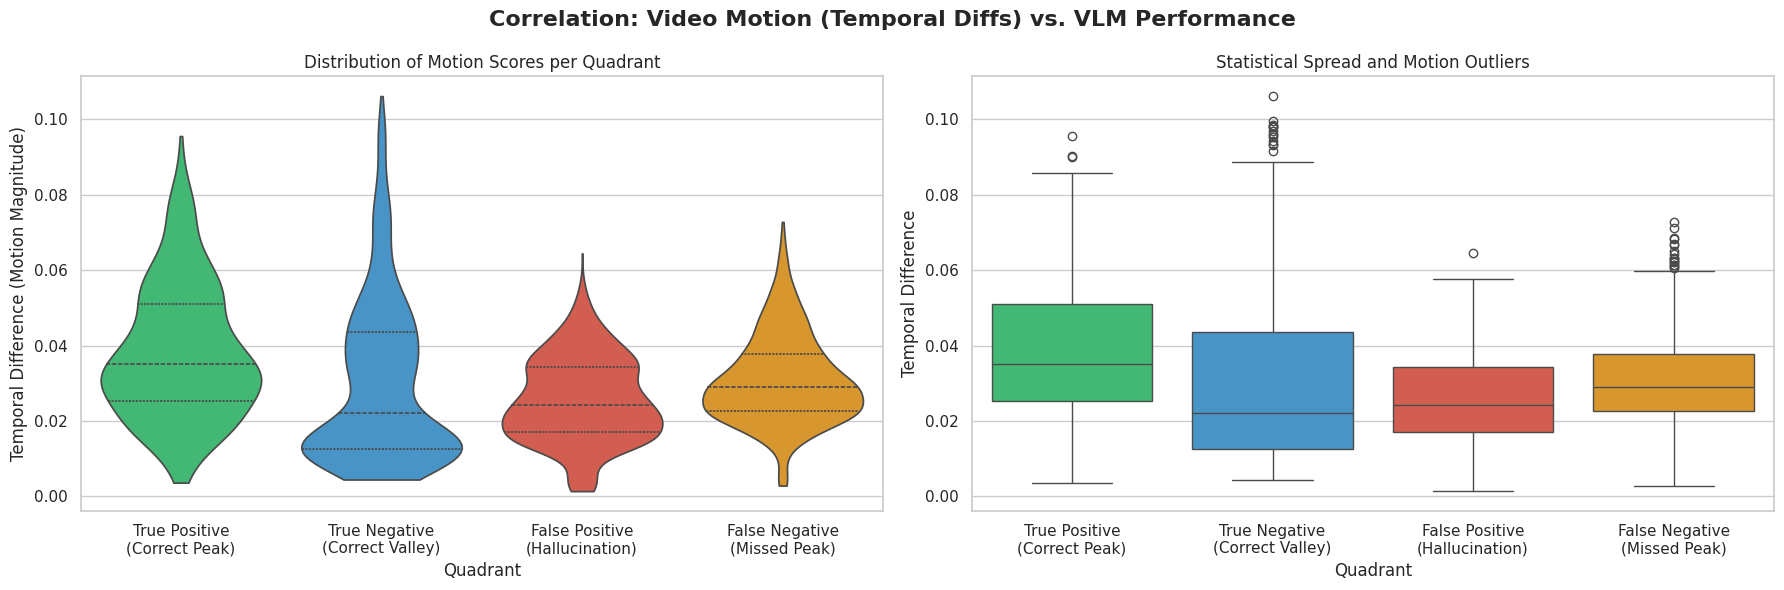

In [52]:
# 1. Compile data into a Pandas DataFrame (Forcing native Python floats)
data = []
for val in tp_temps: data.append({"Quadrant": "True Positive\n(Correct Peak)", "Temporal Diff": float(val)})
for val in tn_temps: data.append({"Quadrant": "True Negative\n(Correct Valley)", "Temporal Diff": float(val)})
for val in fp_temps: data.append({"Quadrant": "False Positive\n(Hallucination)", "Temporal Diff": float(val)})
for val in fn_temps: data.append({"Quadrant": "False Negative\n(Missed Peak)", "Temporal Diff": float(val)})

df = pd.DataFrame(data)

if df.empty:
    print("No data collected! (All banks are empty)")
else:
    # Double safety check: Force the column to be numeric, dropping any weird artifacts
    df["Temporal Diff"] = pd.to_numeric(df["Temporal Diff"], errors="coerce")
    
    # Drop NaNs just in case
    df = df.dropna()

    # 2. Print Statistical Summary
    print("\n" + "="*65)
    print("📊 TEMPORAL DIFF / MOTION CORRELATION REPORT")
    print("="*65)
    summary = df.groupby("Quadrant")["Temporal Diff"].agg(['count', 'mean', 'median', 'std', 'max'])
    print(summary)
    print("="*65 + "\n")

    # 3. Plotting
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Correlation: Video Motion (Temporal Diffs) vs. VLM Performance", fontsize=16, weight='bold')

    palette_dict = {
        "True Positive\n(Correct Peak)": "#2ecc71",
        "True Negative\n(Correct Valley)": "#3498db",
        "False Positive\n(Hallucination)": "#e74c3c",
        "False Negative\n(Missed Peak)": "#f39c12"
    }

    # Plot A: Violin Plot (Distribution Shape)
    sns.violinplot(
        data=df, x="Quadrant", y="Temporal Diff", 
        hue="Quadrant", palette=palette_dict, 
        legend=False, ax=axes[0], cut=0, inner="quartile"
    )
    axes[0].set_title("Distribution of Motion Scores per Quadrant")
    axes[0].set_ylabel("Temporal Difference (Motion Magnitude)")

    # Plot B: Boxplot (Outliers and Medians)
    sns.boxplot(
        data=df, x="Quadrant", y="Temporal Diff", 
        hue="Quadrant", palette=palette_dict, 
        legend=False, ax=axes[1], showfliers=True
    )
    axes[1].set_title("Statistical Spread and Motion Outliers")
    axes[1].set_ylabel("Temporal Difference")

    plt.tight_layout()
    plt.show()

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class VisualSkillPredictor(nn.Module):
    def __init__(self, input_dim=4096): # Note: Check if your VLM uses 3584 or 4096
        super().__init__()
        self.temporal_model = nn.GRU(input_dim, 256, batch_first=True, bidirectional=True)
        
        self.head = nn.Sequential(
            nn.Linear(512, 1),
            nn.Sigmoid()
        )
        self.tp_head = nn.Linear(512, 1) 
        self.fp_head = nn.Linear(512, 1)

    def forward(self, x):
        features, _ = self.temporal_model(x)
        pred_importance = self.head(features)

        # FIX: Changed 'importance' to 'pred_importance'
        tp_logits = pred_importance * self.tp_head(features)
        fp_logits = pred_importance * self.fp_head(features)
        
        return pred_importance.squeeze(-1), tp_logits.squeeze(-1), fp_logits.squeeze(-1)

class VideoSequenceDataset(Dataset):
    def __init__(self, hiddens, gts, tps, fps):
        self.hiddens = hiddens
        self.gts = gts
        self.tps = tps
        self.fps = fps

    def __len__(self):
        return len(self.hiddens)

    def __getitem__(self, idx):
        return self.hiddens[idx], self.gts[idx], self.tps[idx], self.fps[idx]

def pad_collate_fn(batch):
    hiddens, gts, tps, fps = zip(*batch)
    # Pad to the longest video in the batch [Batch, Max_Seq_Len, Dim]
    return (
        pad_sequence(hiddens, batch_first=True),
        pad_sequence(gts, batch_first=True),
        pad_sequence(tps, batch_first=True),
        pad_sequence(fps, batch_first=True)
    )

# Instantiate the loader
seq_dataset = VideoSequenceDataset(dataset_hiddens, dataset_gts, dataset_tps, dataset_fps)
gru_dataloader = DataLoader(seq_dataset, batch_size=4, shuffle=True, collate_fn=pad_collate_fn)

In [60]:
# Initialization
skill_predictor = VisualSkillPredictor(input_dim=dataset_hiddens[0].shape[-1]).to(device)
optimizer = optim.AdamW(skill_predictor.parameters(), lr=1e-4, weight_decay=1e-4)

# Loss functions
# We use BOTH losses on the same output to capture different signal properties
criterion_bce = nn.BCELoss() # Forces absolute Peak vs Valley separation
criterion_mse = nn.MSELoss() # Forces ordinal curve alignment (Correlation)
criterion_binary = nn.BCEWithLogitsLoss() # For Skill Heads (TP/FP)

# Weights
# Increase w_mse to prioritize the Spearman/Kendall correlation metrics
w_bce = 1.0
w_mse = 2.0  
w_tp  = 0.5
w_fp  = 0.5

epochs = 30
skill_predictor.train()

print(f"Training for Correlation + Skills using shared Head...")

for epoch in range(epochs):
    epoch_losses = {'total': 0, 'bce': 0, 'mse': 0, 'tp': 0, 'fp': 0}
    
    for batch in gru_dataloader:
        x, gt, tp_labels, fp_labels = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        
        # Forward pass: pred_imp is the Sigmoid output from self.head
        pred_imp, tp_logits, fp_logits = skill_predictor(x)
        
        # 1. Double-Task the Main Head
        # BCE handles the class confidence, MSE handles the curve correlation
        loss_bce = criterion_bce(pred_imp, gt)
        loss_mse = criterion_mse(pred_imp, gt)
        
        # 2. Skill Head Losses (Error Correction)
        loss_tp = criterion_binary(tp_logits, tp_labels.float())
        loss_fp = criterion_binary(fp_logits, fp_labels.float())
        
        # Combined Loss
        loss = (w_bce * loss_bce) + (w_mse * loss_mse) + (w_tp * loss_tp) + (w_fp * loss_fp)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(skill_predictor.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        epoch_losses['total'] += loss.item()
        epoch_losses['bce'] += loss_bce.item()
        epoch_losses['mse'] += loss_mse.item()
        epoch_losses['tp'] += loss_tp.item()
        epoch_losses['fp'] += loss_fp.item()

    avg = {k: v / len(gru_dataloader) for k, v in epoch_losses.items()}
    print(f"Epoch {epoch+1:02d} | Total: {avg['total']:.4f} | MSE (Corr): {avg['mse']:.4f} | BCE: {avg['bce']:.4f}")

print("\nTraining Complete. self.head is now optimized for Rank Correlation.")

Training for Correlation + Skills using shared Head...
Epoch 01 | Total: 1.6862 | MSE (Corr): 0.1721 | BCE: 0.6488
Epoch 02 | Total: 1.4881 | MSE (Corr): 0.1287 | BCE: 0.5488
Epoch 03 | Total: 1.3700 | MSE (Corr): 0.0992 | BCE: 0.4938
Epoch 04 | Total: 1.3770 | MSE (Corr): 0.1048 | BCE: 0.4919
Epoch 05 | Total: 1.3459 | MSE (Corr): 0.0999 | BCE: 0.4786
Epoch 06 | Total: 1.3104 | MSE (Corr): 0.0943 | BCE: 0.4646
Epoch 07 | Total: 1.2778 | MSE (Corr): 0.0897 | BCE: 0.4533
Epoch 08 | Total: 1.2409 | MSE (Corr): 0.0832 | BCE: 0.4400
Epoch 09 | Total: 1.1990 | MSE (Corr): 0.0761 | BCE: 0.4274
Epoch 10 | Total: 1.1647 | MSE (Corr): 0.0697 | BCE: 0.4124
Epoch 11 | Total: 1.1411 | MSE (Corr): 0.0659 | BCE: 0.4004
Epoch 12 | Total: 1.0967 | MSE (Corr): 0.0582 | BCE: 0.3830
Epoch 13 | Total: 1.0429 | MSE (Corr): 0.0475 | BCE: 0.3612
Epoch 14 | Total: 0.9853 | MSE (Corr): 0.0373 | BCE: 0.3298
Epoch 15 | Total: 0.8753 | MSE (Corr): 0.0161 | BCE: 0.2686
Epoch 16 | Total: 0.8256 | MSE (Corr): 0.0091

In [11]:
good_df = pd.DataFrame(good_skills_pool)
bad_df = pd.DataFrame(bad_skills_pool)
df = pd.concat([good_df, bad_df])
df.head()
df.to_csv(f'{dataset_name}_skills.csv', index=False)

In [14]:
print("Median Temporal Motion by Classification:")
print(df.groupby('type')['temporal_diff'].median().sort_values(ascending=False))

Median Temporal Motion by Classification:
type
fn    1.624038
fp    1.412406
tp    1.192643
tn    0.881850
Name: temporal_diff, dtype: float64


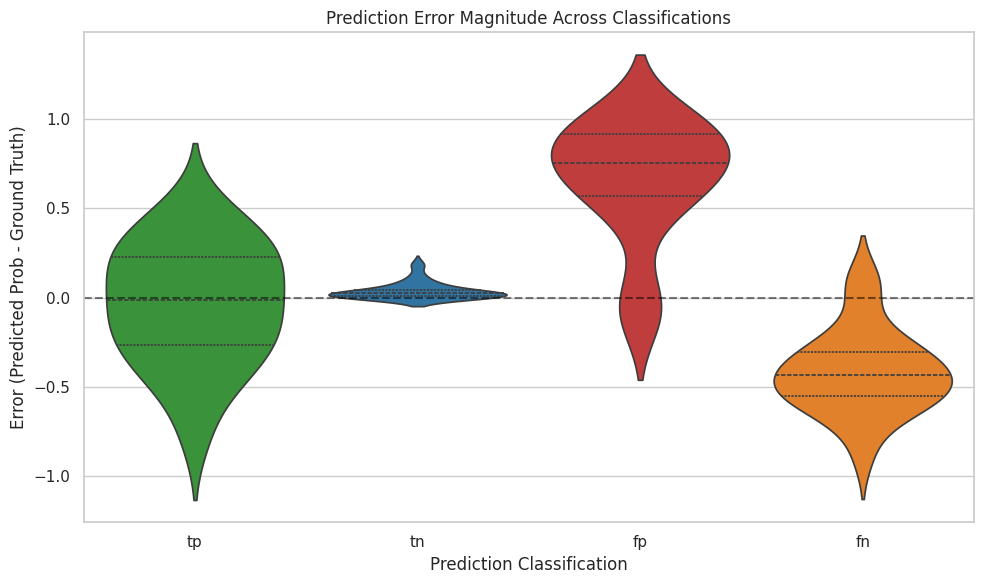

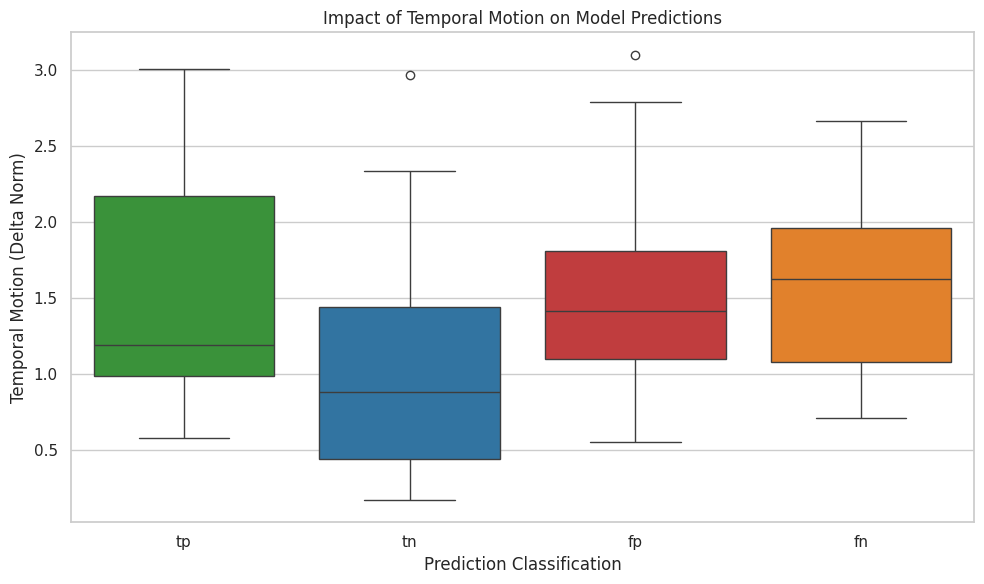

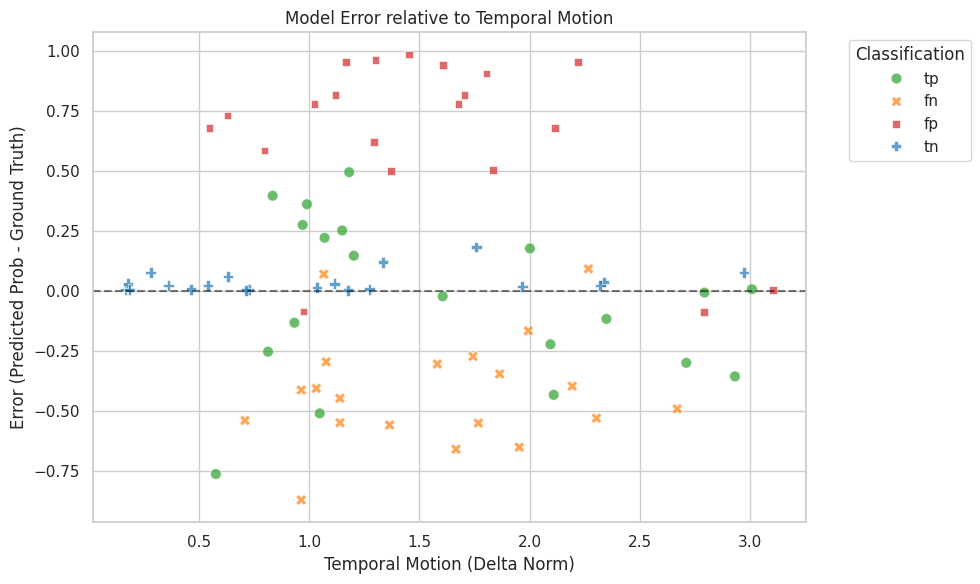

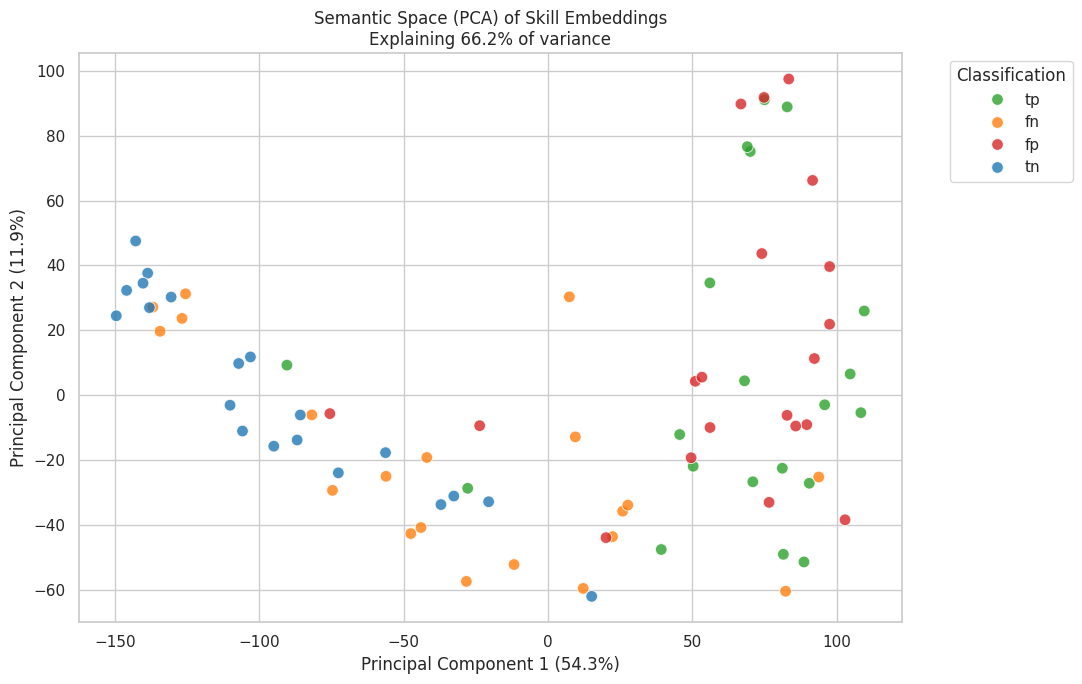

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.decomposition import PCA

# 1. Load and Clean the Data
# Replace 'combined_skills_data.csv' with your actual filename
good_df = pd.DataFrame(good_skills_pool)
bad_df = pd.DataFrame(bad_skills_pool)

df = pd.concat([good_df, bad_df])

# The 'embedding' column is likely saved as a string representation of a list. 
# We need to safely evaluate it back into a numpy array for PCA.
df['embedding'] = df['embedding'].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x)

# Set the visual style for seaborn
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# FIGURE 2: Error Distribution by Type
# ==========================================
# Since error = (Prediction - GT), FPs will be highly positive and FNs highly negative.
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='type', y='error', order=['tp', 'tn', 'fp', 'fn'], 
               palette=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'], inner="quartile")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Prediction Error Magnitude Across Classifications')
plt.xlabel('Prediction Classification')
plt.ylabel('Error (Predicted Prob - Ground Truth)')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: Temporal Motion vs. Errors
# ==========================================
# Are False Positives caused by high temporal motion confusing the VLM?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='type', y='temporal_diff', order=['tp', 'tn', 'fp', 'fn'], 
            palette=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'])
plt.title('Impact of Temporal Motion on Model Predictions')
plt.xlabel('Prediction Classification')
plt.ylabel('Temporal Motion (Delta Norm)')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 4: Bivariate Relationship (Motion vs Error)
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temporal_diff', y='error', hue='type', style='type',
                palette={'tp': '#2ca02c', 'tn': '#1f77b4', 'fp': '#d62728', 'fn': '#ff7f0e'},
                alpha=0.7, s=60)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Model Error relative to Temporal Motion')
plt.xlabel('Temporal Motion (Delta Norm)')
plt.ylabel('Error (Predicted Prob - Ground Truth)')
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 5: PCA of Embeddings in Seaborn
# ==========================================
if not df['embedding'].isna().all():
    # Extract the embeddings into a 2D matrix
    X = np.stack(df['embedding'].values)
    
    # Compute 2D PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X)
    
    # Add back to DataFrame for Seaborn plotting
    df['pca_1'] = pca_result[:, 0]
    df['pca_2'] = pca_result[:, 1]
    
    plt.figure(figsize=(11, 7))
    sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='type', 
                    palette={'tp': '#2ca02c', 'tn': '#1f77b4', 'fp': '#d62728', 'fn': '#ff7f0e'},
                    alpha=0.8, edgecolor='w', s=70)
    
    plt.title(f'Semantic Space (PCA) of Skill Embeddings\nExplaining {sum(pca.explained_variance_ratio_)*100:.1f}% of variance')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
# 2. Testing Phase: Use Skills for Reprompting
print(f"\nEvaluating test set with acquired skills...")
test_set = split['test_keys']
split_results = []

if "tvsum" in args.split_file.lower() and get_gt is not None:
    tvsum_user_scores = get_gt('TVSum')
else:
    tvsum_user_scores = None

for video_id in test_set:
    item = next((m for m in manifest if m['h5_key'] == video_id), None)
    if not item: continue
    
    video_path, title, dataset_name = item["video_path"], item["title"], item["dataset"]
    picks, h5_path = item["picks"], summe_h5 if dataset_name == "summe" else tvsum_h5
    
    print(f"\n[EVAL] {dataset_name}/{item['video_name']} | \"{title}\"")
    
    # Run Inference w/ Skills reprompting
    dataset = VideoSegmentDataset(video_path, segment_length=32, width=896, height=672, picks=picks)
    loader = DataLoader(dataset, batch_size=None, shuffle=False, num_workers=4)

    # Extract Title Keywords
    if args.model_type == "minicpm":
        cleaned_title, keywords = minicpm_extract_title_and_keywords(title, model, processor)
    else:
        cleaned_title, keywords = qwen_extract_title_and_keywords(title, model)

    all_p_yes, all_p_no, all_hidden_states = [], [], []
    for frames, _, _ in loader:
        if args.model_type == "minicpm":
            p_yes, p_no, _, _, hidden_states_test = minicpm_inference(frames, cleaned_title, keywords, model, processor, yes_id, no_id)
        else:
            p_yes, p_no, _, _, _ = qwen_inference(frames, cleaned_title, keywords, model, yes_id, no_id)

        all_p_yes.append(p_yes.detach().cpu().float().numpy())
        all_p_no.append(p_no.detach().cpu().float().numpy())
        all_hidden_states.append(hidden_states_test.detach().cpu().float().numpy())

    raw_p_yes, raw_p_no = np.concatenate(all_p_yes), np.concatenate(all_p_no)
    hidden_states_test = np.concatenate(all_hidden_states, axis=0)

    res = compute_video_metrics(
        yes_scores=raw_p_yes, 
        no_scores=raw_p_no, 
        h5_path=h5_path, 
        h5_key=video_id, 
        video_name=item['video_name'],
        dataset_name=dataset_name, 
        user_scores=tvsum_user_scores,
        use_advanced_scoring=True
    )
    
    print(f"  --> F-Score: {res['f_score']:.4f} | Kendall: {res['kendall']:.4f} | Spearman: {res['spearman']:.4f}")


Evaluating test set with acquired skills...

[EVAL] summe/Playing_on_water_slide | "Playing on water slide"
  --> F-Score: 0.5978 | Kendall: 0.0155 | Spearman: 0.0174

[EVAL] summe/Uncut_Evening_Flight | "Uncut Evening Flight"
  --> F-Score: 0.1912 | Kendall: 0.0414 | Spearman: 0.0458

[EVAL] summe/playing_ball | "playing ball"


In [ ]:
df[df['type'] == "tp"]


In [ ]:
# Plotting a histogram to see distribution overlap
plt.hist(df[df['type'] == "tp"]["contrast"], bins=20, alpha=0.6, label="TP")
plt.hist(df[df['type'] == "fp"]["contrast"], bins=20, alpha=0.6, label="FP")

plt.xlabel("Logit Contrast (Yes - No)")
plt.ylabel("Frequency")
plt.legend()
plt.title("TP vs FP Contrast Distribution")
plt.show()

In [ ]:
df['contrast'] = df['logit_yes'] - df['logit_no']

# Print the stats for True Positives
print("TP Contrast Mean/Std:", 
      df[df['type'] == "tp"]["contrast"].mean(), 
      df[df['type'] == "tp"]["contrast"].std())

# Print the stats for False Positives
print("FP Contrast Mean/Std:", 
      df[df['type'] == "fp"]["contrast"].mean(), 
      df[df['type'] == "fp"]["contrast"].std())

In [ ]:
import numpy as np

# 1. Calculate the Global Centroid per video (the "Average" look of that video)
video_centroids = {}
for vid in df['video_id'].unique():
    vid_frames = df[df['video_id'] == vid]
    if len(vid_frames) > 0:
        # Get all embeddings for this video
        embeddings_stack = np.stack(vid_frames['embedding'].values)
        video_centroids[vid] = np.mean(embeddings_stack, axis=0)

# 2. Compute the Semantic Deviation (Cosine Distance from the video mean)
def get_deviation(row):
    vid = row['video_id']
    if vid in video_centroids:
        mean_emb = video_centroids[vid]
        curr_emb = row['embedding']
        # Cosine Similarity calculation
        norm_prod = (np.linalg.norm(curr_emb) * np.linalg.norm(mean_emb)) + 1e-8
        cos_sim = np.dot(curr_emb, mean_emb) / norm_prod
        return 1.0 - cos_sim # Cosine Distance
    return np.nan

df['dist_to_mean'] = df.apply(get_deviation, axis=1)

# 3. Compare TPs vs FPs using the new column
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['type'].isin(['tp', 'fp'])], x='dist_to_mean', hue='type', 
            fill=True, palette={'tp': '#2ca02c', 'fp': '#d62728'}, common_norm=False)

plt.title('Semantic Deviation: Are TPs more "Unique" than FPs?')
plt.xlabel('Cosine Distance from Video Mean')
plt.ylabel('Density')
plt.show()

dist_summary = df[df['type'].isin(['tp', 'fp'])].groupby('type')['dist_to_mean'].mean()
print("Average Semantic Deviation (Higher = More unique/less like background):")
print(dist_summary)

## 4. Analysis

In [ ]:
plt.figure(figsize=(9, 6))
weights = np.ones_like(all_errors_split) / len(all_errors_split)
plt.hist(all_errors_split, bins=15, weights=weights, color='turquoise', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Calibration (Ideal)')
    
plt.title(f'Distribution of Prediction Errors')
plt.xlabel('Model Error')
plt.ylabel('Sample Frequency')

xmin, xmax = plt.xlim()
plt.axvspan(xmin, 0, color='blue', alpha=0.1, label='Under-predict', zorder=1)
plt.axvspan(0, xmax, color='red', alpha=0.05, label='Over-predict', zorder=1)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()